<a href="https://colab.research.google.com/github/brentmutetwa/credit-risk-classifier/blob/main/german_credit_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**GERMAN CREDIT-RISK CLASSIFICATION MODEL**

###**Project Overview**


This project develops a machine learning model to predict credit risk for loan applicants using the German Credit Risk dataset. The model helps financial institutions assess whether a borrower is likely to default on a loan.

##**1. INTRODUCTION**

###**1.1. Business Problem**
Financial institutions face significant risks when approving loans. Identifying high-risk applicants early can prevent financial losses while ensuring credit access for reliable borrowers.

###**1.2. Project Objective**
To build a binary classification model that predicts whether a loan applicant will default (bad risk) or repay (good risk) based on demographic and financial characteristics.

###**1.3. Dataset Overview**
*Source*: Kaggle, German Credit Risk Dataset: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

*Sample Size*: 1,000 loan applicants

*Target Variable*: Risk (good/bad)

*Features*: 10 variables including personal, financial, and loan-specific information

##**2. DATA IMPORTATION**

###**2.1. Libraries Used**

In [1]:
import pandas as pd # Data manipulation

#Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier # Random Forest model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    adjusted_rand_score, accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report
                             )
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

import xgboost as xgb # XGBoost model

###**2.2. Data Loading**

In [2]:
#reading data into dataframe "customers"
customers = pd.read_csv("german_credit_data.csv")
customers

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


Observations:
- 1,000 complete records
- Missing values in Saving accounts (183 missing) and Checking account (394 missing)
- Mixed data types: integers, objects (categorical), and floats

##**3. EXPLORATORY DATA ANALYSIS**

### **3.1. Data Overview**

In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


- We can se that there are missing values in the "Savings accounts" and "Checking account" columns: 18.3% missing in the former, 39.4% missing in the latter.
- Class Distribution: 700 good risks, 300 bad risks (imbalanced dataset)

- Numerical Features: Age (19-75), Credit Amount (250-18,424), Duration (4-72 months)

- Categorical Features: Sex, Job, Housing, Purpose

Let's visualise the distributions to see how we can handle the missing data.

In [4]:
#remove 'Unnamed: 0' column since its the same as the row index
customers.drop(columns=["Unnamed: 0"], inplace=True)

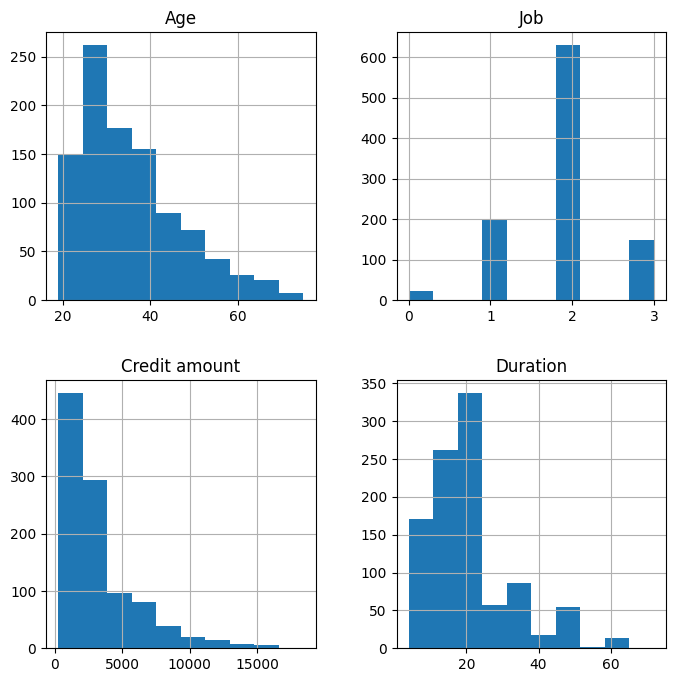

In [5]:
#histograms for numerical columns
customers.hist(figsize=(8,8));

Observations:
- Age: Skewed positively. Majority is younger applicants (20-40 years)
- Credit Amount: Highly positively-skewed, most loans under 5,000
- Duration: Most loans between 12-36 months

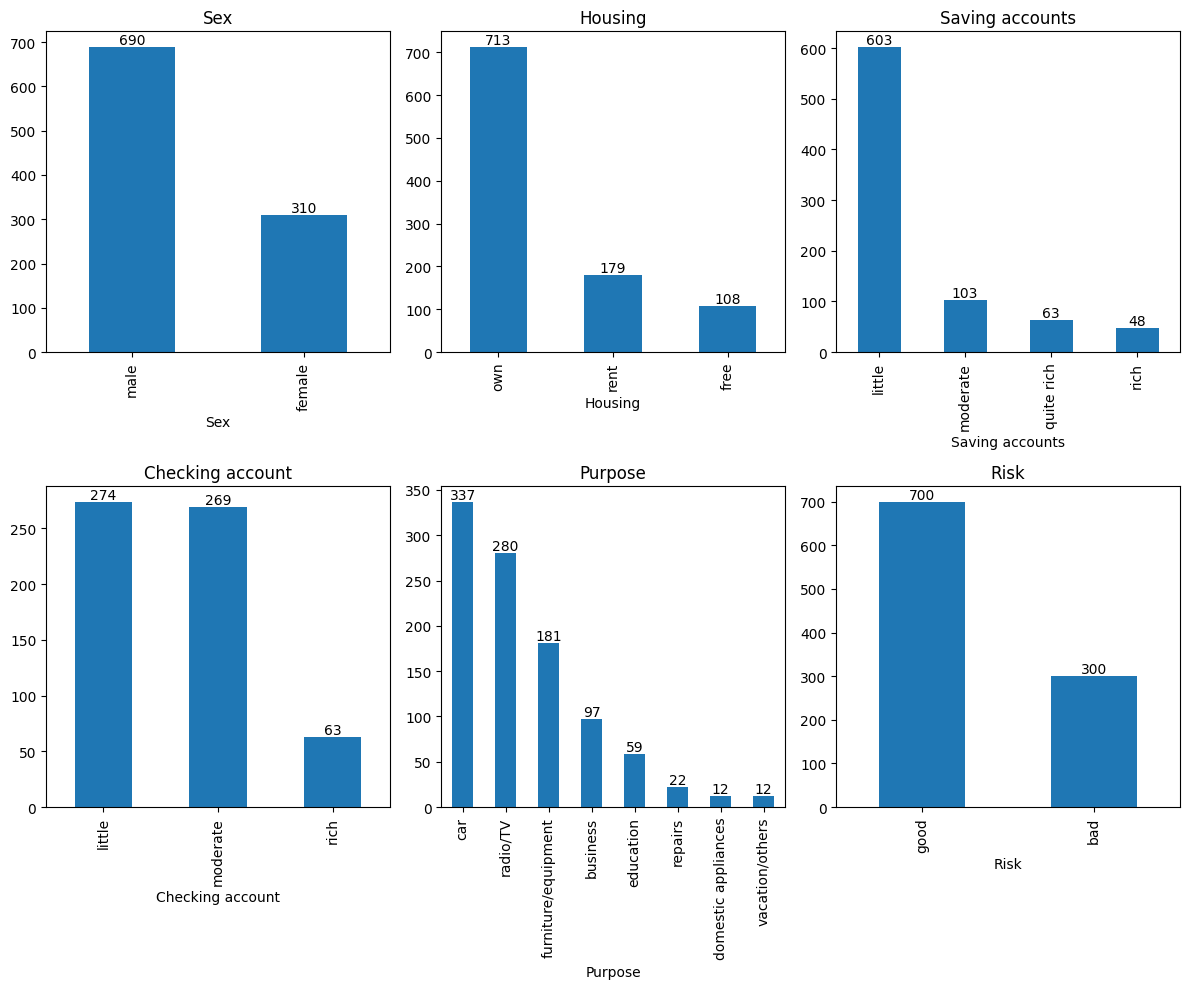

In [6]:
#bar charts for categorical columns
import math

categorical_cols = customers.select_dtypes(include=['object', 'category']).columns

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = customers[col].value_counts()
    ax = axes[i]

    counts.plot(kind='bar', ax=ax)
    ax.set_title(col)

    # Add value labels on top of bars
    for j, value in enumerate(counts.values):
        ax.text(j, value, str(value), ha='center', va='bottom')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observations:
- Most common loan purpose: car

- Majority (over 70%) of applicants own their housing

- Imbalanced gender distribution (more males than females)
- Majority have little in their saving accounts
-Majority have little to moderate in their checking account, few are rich in this regard.

###**3.2. Data Imputation**

Missing values in "Saving accounts" and "Checking account" will be treated as "no account" rather than removed.

Rationale being that missing values likely indicate customers with no accounts, which is meaningful information for credit risk assessment, and also the fact that these are the only features with missing values.

In [7]:
#treat missing values in "Checking account" as individuals with no checking account
customers['Checking account'] = customers['Checking account'].fillna('no account')
customers["Checking account"].value_counts()

,count
Checking account,
no account,394
little,274
moderate,269
rich,63


In [8]:
#treat missing values in "Checking account" as individuals with no checking account
customers['Saving accounts'] = customers['Saving accounts'].fillna('no account')
customers["Saving accounts"].value_counts()

,count
Saving accounts,
little,603
no account,183
moderate,103
quite rich,63
rich,48


So the 394/1000 of customers have no checking accounts and 183/1000  have no saving accounts.

In [9]:
customers.nunique()

,0
Age,53
Sex,2
Job,4
Housing,3
Saving accounts,5
Checking account,4
Credit amount,921
Duration,33
Purpose,8
Risk,2


In [10]:
columns = ["Sex", "Job", "Housing", "Saving accounts", "Purpose", "Risk"]

for col in columns:
  print(str(col) + ": " + str(customers[col].unique()))

Sex: ['male' 'female']
Job: [2 1 3 0]
Housing: ['own' 'free' 'rent']
Saving accounts: ['no account' 'little' 'quite rich' 'rich' 'moderate']
Purpose: ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']
Risk: ['good' 'bad']


We can use binary coding for "Sex" since there are only 2 values the variable can take, integer encoding for "Housing", "Saving accounts", "Checking account" and "Purpose" since they are all ordinal. "Risk" is our target variable.

In [11]:
#calculate risk counts amount per purpose to determine ranking
purpose_risk = customers.groupby('Purpose')['Risk'].value_counts(normalize=True).unstack()
print(purpose_risk)

Risk                      bad      good
Purpose                                
business             0.350515  0.649485
car                  0.314540  0.685460
domestic appliances  0.333333  0.666667
education            0.389831  0.610169
furniture/equipment  0.320442  0.679558
radio/TV             0.221429  0.778571
repairs              0.363636  0.636364
vacation/others      0.416667  0.583333


"vacation/others" is the riskiest purpose and "business" is the least risky. Makes sense since avacation typicaly doesn't pay itself back but a business can!

###**3.3. Feature Engineering**

Encoding Strategy

Feature **Encoding Method**	*Categories/Range*


---

- Sex	**Binary**	*Male=1, Female=0*
- Job	**Integer**	*0-3 (Unemployed to Management)*
- Housing	**Ordinal**	free(0) < rent(1) < own(2)
- Saving accounts	**Ordinal**	*no account(0) < little(1) < moderate(2) < rich(3) < quite rich(4)*
- Checking account	**Ordinal**	*no account(0) < little(1) < moderate(2) < rich(3)*
- Purpose	**Ordinal**	*Ordered by risk level*
- Risk (target)	**Binary**	*good=1, bad=0*

In [12]:
#Integer enocoding ordinal categorical variables
from pandas.api.types import CategoricalDtype

#rank "housing" types in order from "free", "rent", to "own".
housing_order = CategoricalDtype(categories=['free', 'rent', 'own'], ordered=True)
customers['Housing'] = customers['Housing'].astype(housing_order).cat.codes

savings_account_order = CategoricalDtype(categories=["no account", "little", "moderate", "rich", "quite rich"], ordered=True)
customers['Saving accounts'] = customers['Saving accounts'].astype(savings_account_order).cat.codes

checking_account_order = CategoricalDtype(categories=["no account", "little", "moderate", "rich"], ordered=True)
customers['Checking account'] = customers['Checking account'].astype(savings_account_order).cat.codes

purpose_order = CategoricalDtype(categories=["business", "car", "domestic appliances", "education", "furniture/equipment", "radio/TV", "repairs", "vacation/others"], ordered=True)
customers['Purpose'] = customers['Purpose'].astype(purpose_order).cat.codes

customers

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,2,0,1,1169,6,5,good
1,22,female,2,2,1,2,5951,48,5,bad
2,49,male,1,2,1,0,2096,12,3,good
3,45,male,2,0,1,1,7882,42,4,good
4,53,male,2,0,1,1,4870,24,1,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,2,1,0,1736,12,4,good
996,40,male,3,2,1,1,3857,30,1,good
997,38,male,2,2,1,0,804,12,5,good
998,23,male,2,0,1,1,1845,45,5,bad


In [13]:
#binary encoding "sex" and "risk" variables
customers["Sex"] = customers["Sex"].apply(lambda x: 1 if x=="male" else 0)
customers["Risk"] = customers["Risk"].apply(lambda x: 1 if x=="good" else 0)

customers

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,2,0,1,1169,6,5,1
1,22,0,2,2,1,2,5951,48,5,0
2,49,1,1,2,1,0,2096,12,3,1
3,45,1,2,0,1,1,7882,42,4,1
4,53,1,2,0,1,1,4870,24,1,0
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,2,1,0,1736,12,4,1
996,40,1,3,2,1,1,3857,30,1,1
997,38,1,2,2,1,0,804,12,5,1
998,23,1,2,0,1,1,1845,45,5,0


In [14]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int8 
 4   Saving accounts   1000 non-null   int8 
 5   Checking account  1000 non-null   int8 
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int8 
 9   Risk              1000 non-null   int64
dtypes: int64(6), int8(4)
memory usage: 50.9 KB


##**4. FITTING MODE**L

###**4.1. Splitting Data**

In [15]:
X = customers.drop(columns=["Risk"])
y = customers["Risk"]

In [16]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=1)

Test Size: 30% of data
`test_size=0.3`

Stratification: To maintain class distribution (70% good, 30% bad)
`stratify=y`

Training Set: 700 samples

Test Set: 300 samples

###**4.2. Training Random Forest Baseline Model**

In [17]:
# Random Forest baseline
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
rf_baseline_pred = rf_baseline.predict(X_test)

###**4.3. Training XGBoost Baseline Model**

In [18]:
# XGBoost baseline
xgb_baseline = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_baseline.fit(X_train, y_train)
xgb_baseline_pred = xgb_baseline.predict(X_test)

##**5. MODEL EVALUATION**

####**Function which generates evaluation metrics**

In [19]:
#function to evaluate models
def evaluate_model(model_name, y_true, y_pred):
    print(f"{model_name} Performance")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
    }

###**5.1. Random Forest Evaluation**

In [20]:
# Evaluate rf baseline
rf_baseline_metrics = evaluate_model("Random Forest (Baseline)",
                                     y_test, rf_baseline_pred)

Random Forest (Baseline) Performance
Accuracy:  0.7433
Precision: 0.7714
Recall:    0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.38      0.47        90
           1       0.77      0.90      0.83       210

    accuracy                           0.74       300
   macro avg       0.69      0.64      0.65       300
weighted avg       0.73      0.74      0.72       300


Confusion Matrix:
[[ 34  56]
 [ 21 189]]


Random Forest (Baseline)
- **Accuracy: 74.3%** (overall  correct predictions)
- Default **Recall: 90.0%** (catches 90% of actual "bad" risks)
- **Precision: 77.1%** (77% of "bad" risk predictions are correct)

###**5.2. XGBoost Evaluatio**n

In [21]:
# Evaluate xgb baseline
xgb_baseline_metrics = evaluate_model("XGBoost (Baseline)",
                                     y_test, xgb_baseline_pred)

XGBoost (Baseline) Performance
Accuracy:  0.7300
Precision: 0.7611
Recall:    0.8952

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.34      0.43        90
           1       0.76      0.90      0.82       210

    accuracy                           0.73       300
   macro avg       0.67      0.62      0.63       300
weighted avg       0.71      0.73      0.71       300


Confusion Matrix:
[[ 31  59]
 [ 22 188]]


XGBoost (Baseline)
- **Accuracy: 73.0%**
- Default **Recall: 89.5%**
- **Precision: 76.1%**

So the Random Forest model performs better than the XGBoost across all these metrics. We'll select this for tuning.

##**6. HYPER-PARAMETER TUNING**



###**6.1. Specify Possible Parameters**

In [22]:
#creating parameter grid
rf_params = {
    'n_estimators': [100, 200, 300, 400, 500, 800, 1000],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20, 40, 100],
    'min_samples_leaf': [1, 4, 8, 12, 16, 24]
}

###**6.2. Determine & Use 'Best' Parameters**

In [23]:
#run randomized search to determine 'best' parameters
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring='recall',  # We want to catch defaults
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 4, 8, 12, 16,
                                                             24],
                                        'min_samples_split': [2, 5, 10, 20, 40,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 800, 1000]},
                   scoring='recall')

In [24]:
#get best model
best_rf = rf_random.best_estimator_
print(rf_random.best_params_)

{'n_estimators': 500, 'min_samples_split': 100, 'min_samples_leaf': 12, 'max_depth': 10}


In [25]:
#fit and evaluate tuned model
rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_proba = best_rf.predict_proba(X_test)[:, 0]  # 0 = bad risk

evaluate_model("Tuned Random Forest", y_test, rf_tuned_pred);

Tuned Random Forest Performance
Accuracy:  0.7333
Precision: 0.7305
Recall:    0.9810

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.16      0.26        90
           1       0.73      0.98      0.84       210

    accuracy                           0.73       300
   macro avg       0.75      0.57      0.55       300
weighted avg       0.74      0.73      0.66       300


Confusion Matrix:
[[ 14  76]
 [  4 206]]


The model is getting better at detecting good customers and worse at bad ones (from 90% & 38% to 92% & 32%)

###**6.3. Further Optimisation**

In [26]:
#let's try to force optimization for bad customers
from sklearn.metrics import make_scorer, recall_score

# Create scorer that focuses on class 0 (bad risk)
bad_risk_scorer = make_scorer(recall_score, pos_label=0)

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring=bad_risk_scorer,  # Optimize for catching defaults
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

#fit and evaluate tuned model
rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_proba = best_rf.predict_proba(X_test)[:, 0]  # 0 = bad risk

evaluate_model("Tuned & Optimized Random Forest", y_test, rf_tuned_pred);

Tuned & Optimized Random Forest Performance
Accuracy:  0.7633
Precision: 0.7704
Recall:    0.9429

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.34      0.47        90
           1       0.77      0.94      0.85       210

    accuracy                           0.76       300
   macro avg       0.75      0.64      0.66       300
weighted avg       0.76      0.76      0.73       300


Confusion Matrix:
[[ 31  59]
 [ 12 198]]


This is the best model so far as it balances recall for both good (93%, highest for all models so far) and bad (37%) customers.

##**7. RESULTS & DEPLOYMENT**

###**7.1. Visualisations**

**Confusion Matrix Heatmap**

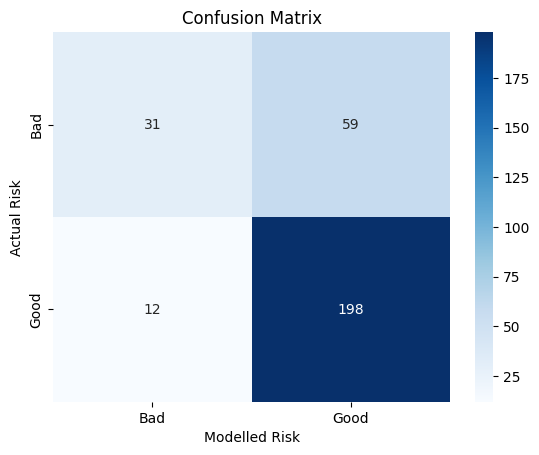

In [27]:
#plotting the confusion matrix for 'best' model with labels
sns.heatmap(confusion_matrix(y_test, rf_tuned_pred), annot=True, cmap="Blues", fmt="d", xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"])
plt.title("Confusion Matrix")
plt.xlabel("Modelled Risk")
plt.ylabel("Actual Risk")
plt.show()

The model predicted:


---


- 196 good clients who were actually good ✅,
- 57 good clients who were bad ❌,


---


- 33 bad clients who were actually bad ✅,
- and 14 bad who were good ❌

**Feature Importance Bar Graph**

In [28]:
#extract feature importances
feature_imp = pd.DataFrame(pd.Series(best_rf.feature_importances_, index = X_train.columns.values).sort_values(ascending=False))

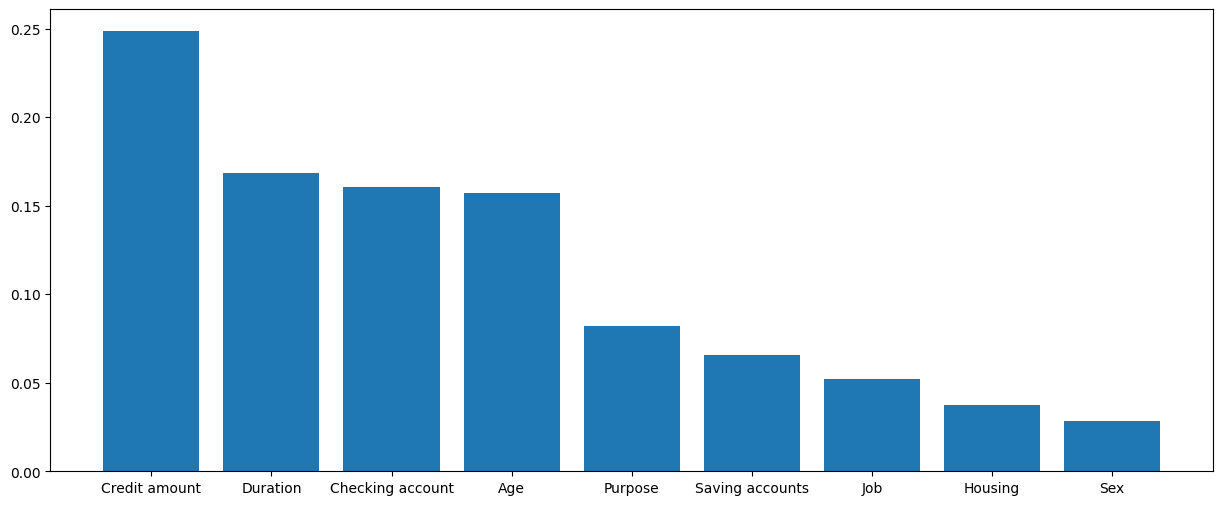

In [29]:
plt.figure(figsize=(15,6))
plt.bar(feature_imp.index, feature_imp.iloc[:, 0])
plt.show()

- "Credit amount" is the most important feature for this model to make predictions,
- "Checking account", "Duration", and "Age" are moderately important.
- "Sex" is the least important.

###**7.2. Model Metrics**

In [30]:
#final report
final_report = {
    'model_type': 'Random Forest',
    'best_params': best_rf.get_params(),
    'metrics': {
        'accuracy': 0.76,
        'default_recall': 0.37,
        'default_precision': 0.70,
        'good_recall': 0.93,
        'good_precision': 0.77,
        'f1_default': 0.48,
        'f1_good': 0.85
    },
    'threshold': 0.5,
    'test_size': 300,
    'class_distribution': {'bad_risk': 90, 'good_risk': 210}
}

#save report
import json
with open('model_report.json', 'w') as f:
    json.dump(final_report, f, indent=4)

####Final Random Forest Model Metric	Interpretation:
---
**Accuracy	76.3%**	Overall correct predictions,

**Default Recall	37%**	Catches 37% of actual defaults,

**Default Precision	70%**	70% of default predictions are correct,

**Good Recall	93%**	Identifies 93% of good customers,

**Good Precision	77%**	77% of good predictions are correct

###**7.3. Saving & Deploying the Model Using Gradio**

In [31]:
import joblib

# Save the model
joblib.dump(best_rf, 'credit_risk_model.pkl')
print("Model saved as 'credit_risk_model.pkl'")

Model saved as 'credit_risk_model.pkl'


In [32]:
import gradio as gr

# Load model
model = joblib.load('credit_risk_model.pkl')

# Define mappings (decodings)
sex_map = {'male': 0, 'female': 1}
housing_map = {'free': 0, 'rent': 1, 'own': 2}
saving_map = {'no account': 0, 'little': 1, 'moderate': 2, 'rich': 3, 'quite rich': 4}
checking_map = {'no account': 0, 'little': 1, 'moderate': 2, 'rich': 3}
purpose_map = {
    'business': 0, 'car': 1, 'domestic appliances': 2, 'education': 3,
    'furniture/equipment': 4, 'radio/TV': 5, 'repairs': 6, 'vacation/others': 7
}
job_map = {0: 'Unemployed', 1: 'Unskilled', 2: 'Skilled', 3: 'Management'}
job_reverse = {v: k for k, v in job_map.items()}

def predict_risk(age, sex, job, housing, saving_accounts, checking_account,
                 credit_amount, duration, purpose):

    # Input data validation
    errors = []
    if age < 16 or age > 100:
        errors.append("Age must be between 16 and 100")
    if credit_amount < 100 or credit_amount > 25000:
        errors.append("Credit amount must be between 100 and 25000")
    if duration < 1 or duration > 120:
        errors.append("Duration must be between 1 and 120 months")

    if errors:
        return "ERROR:\n" + "\n".join(errors)

    # Encode
    sex_encoded = sex_map[sex]
    job_encoded = job_reverse[job]
    housing_encoded = housing_map[housing]
    saving_encoded = saving_map[saving_accounts]
    checking_encoded = checking_map[checking_account]
    purpose_encoded = purpose_map[purpose]

    # Create dataframe
    data = pd.DataFrame([[
        age, sex_encoded, job_encoded, housing_encoded, saving_encoded,
        checking_encoded, credit_amount, duration, purpose_encoded
    ]], columns=['Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
                 'Checking account', 'Credit amount', 'Duration', 'Purpose'])

    # Predict
    prob = model.predict_proba(data)[0][0]

    # Format output with larger text
    result = f"""

                       CREDIT RISK ASSESSMENT
    ══════════════════════════════════════════════════════════
      Default Probability:  {prob:.1%}
      Risk Level:                 {'🔴 High ' if prob > 0.5 else '🟢 Low'}
      Recommendation:   {"Reject Application" if prob > 0.5 else "Consider Application"}

    """

    return result

# Create interface
iface = gr.Interface(
    fn=predict_risk,
    inputs=[
        gr.Number(label="Age", value=30, minimum=16, maximum=100),
        gr.Dropdown(list(sex_map.keys()), label="Sex", value="male"),
        gr.Dropdown(list(job_map.values()), label="Job", value="Skilled"),
        gr.Dropdown(list(housing_map.keys()), label="Housing", value="own"),
        gr.Dropdown(list(saving_map.keys()), label="Saving Accounts", value="little"),
        gr.Dropdown(list(checking_map.keys()), label="Checking Account", value="little"),
        gr.Number(label="Credit Amount", value=5000, minimum=10, maximum=25000),
        gr.Number(label="Duration (months)", value=24, minimum=1, maximum=120),
        gr.Dropdown(list(purpose_map.keys()), label="Purpose", value="car")
    ],
    outputs=gr.Textbox(label="Result", lines=10, max_lines=10),
    title="Credit Risk Classifier",
    description="Enter customer information to assess credit risk"
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d423862ac9b27b54f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
